# Project 2 – Supervised Classification on German Credit Risk 

## CSCI 440 – Artificial Intelligence and Neural Networks  
Spring 2026  
Group 4

### Objective  
The objective of this project is to build a supervised classification model to predict whether a credit applicant is a good or bad credit risk using the German Credit dataset from OpenML.

This is a binary classification problem evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

In [45]:
from sklearn.datasets import fetch_openml

credit = fetch_openml(data_id=31, as_frame=True)

X = credit.data
y = credit.target

X.shape, y.shape

((1000, 20), (1000,))

## 1. Data Collection

The German Credit dataset contains 1000 instances and 20 features describing financial and demographic characteristics of credit applicants.

The target variable indicates whether the applicant is a good or bad credit risk.

In [46]:
y.value_counts()

class
good    700
bad     300
Name: count, dtype: int64

In [47]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   checking_status         1000 non-null   category
 1   duration                1000 non-null   int64   
 2   credit_history          1000 non-null   category
 3   purpose                 1000 non-null   category
 4   credit_amount           1000 non-null   int64   
 5   savings_status          1000 non-null   category
 6   employment              1000 non-null   category
 7   installment_commitment  1000 non-null   int64   
 8   personal_status         1000 non-null   category
 9   other_parties           1000 non-null   category
 10  residence_since         1000 non-null   int64   
 11  property_magnitude      1000 non-null   category
 12  age                     1000 non-null   int64   
 13  other_payment_plans     1000 non-null   category
 14  housing                 1000 non-nul

## 2. Data Exploration

The dataset contains both numerical and categorical features.  

The class distribution shows approximately 70% good credit and 30% bad credit, indicating slight class imbalance.

In [48]:
X.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes


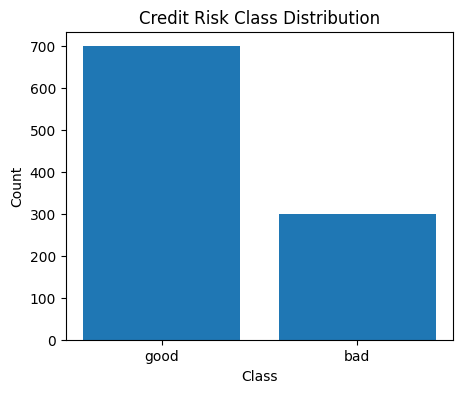

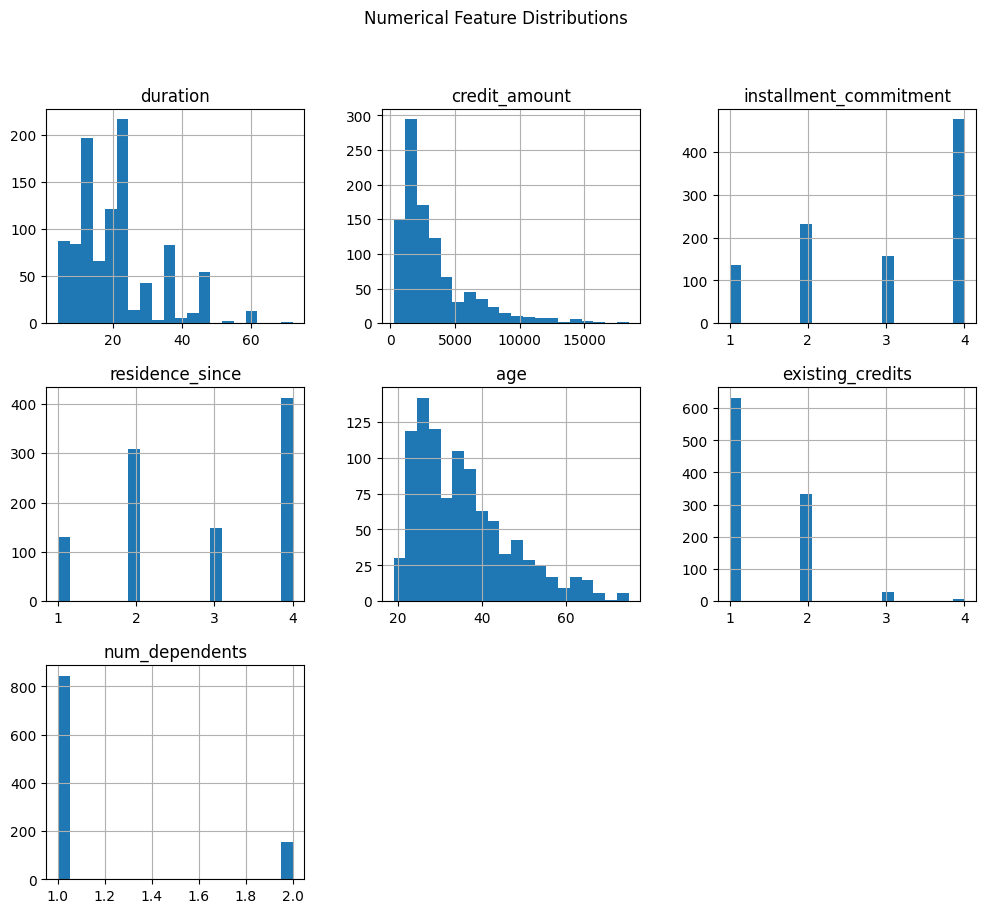

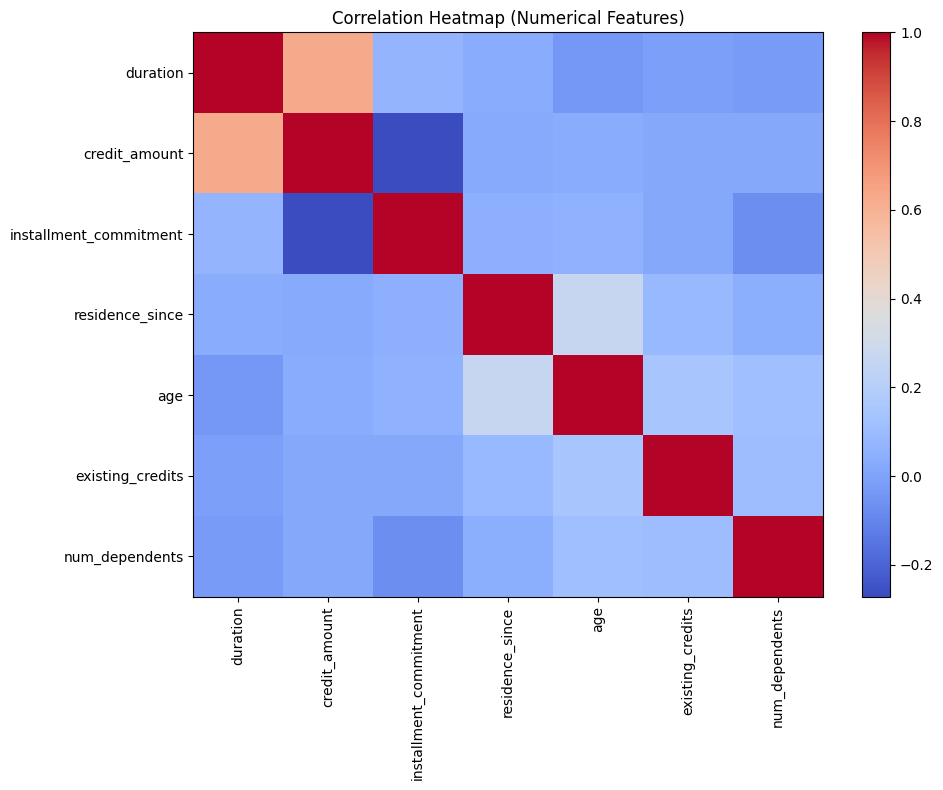

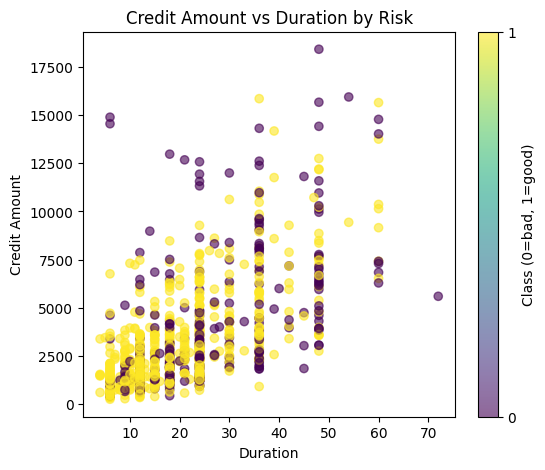

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Make y numeric for plotting (bad=0, good=1)
y_num = y.astype(str).map({"bad": 0, "good": 1})

# 1) Class distribution
plt.figure(figsize=(5,4))
counts = y.astype(str).value_counts()
plt.bar(counts.index, counts.values)
plt.title("Credit Risk Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# 2) Numerical feature distributions
num_cols = X.select_dtypes(include=['int64','float64']).columns
X[num_cols].hist(figsize=(12,10), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

# 3) Correlation heatmap (numerical only)
corr = X[num_cols].corr()

plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

# 4) Credit amount vs Duration colored by class
plt.figure(figsize=(6,5))
sc = plt.scatter(X["duration"], X["credit_amount"], c=y_num, alpha=0.6)
plt.title("Credit Amount vs Duration by Risk")
plt.xlabel("Duration")
plt.ylabel("Credit Amount")
plt.colorbar(sc, ticks=[0,1], label="Class (0=bad, 1=good)")
plt.show()

## Data Exploration Findings

The dataset shows a class imbalance with significantly more good credit applicants than bad credit applicants. This suggests the classifier may become biased toward predicting good credit and motivates the use of balanced evaluation metrics such as F1-score.

The numerical feature distributions indicate that credit amount is highly right-skewed, meaning most applicants request small loans while a few request very large amounts. Duration also varies widely, suggesting longer loans may be associated with increased risk.

From the scatter plot of credit amount versus duration, bad credit cases appear more frequently among applicants requesting higher loan amounts over longer periods, indicating a potential relationship between loan size, repayment time, and risk.

The correlation heatmap shows that most numerical features are weakly correlated, implying the model must rely on combinations of features rather than a single dominant predictor. This justifies using nonlinear models such as Random Forest.

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train.shape, X_test.shape, y_train.value_counts(normalize=True)

((800, 20),
 (200, 20),
 class
 good    0.7
 bad     0.3
 Name: proportion, dtype: float64)

## 3. Train-Test Split

The dataset was split into 80% training and 20% testing using stratified sampling.

Stratification ensures that the class proportions remain consistent in both sets.

In [51]:
import pandas as pd

num_cols = X_train.select_dtypes(include=["int64"]).columns
cat_cols = X_train.select_dtypes(include=["category", "object"]).columns

num_cols, cat_cols

(Index(['duration', 'credit_amount', 'installment_commitment',
        'residence_since', 'age', 'existing_credits', 'num_dependents'],
       dtype='str'),
 Index(['checking_status', 'credit_history', 'purpose', 'savings_status',
        'employment', 'personal_status', 'other_parties', 'property_magnitude',
        'other_payment_plans', 'housing', 'job', 'own_telephone',
        'foreign_worker'],
       dtype='str'))

In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

## 4. Data Preprocessing

A preprocessing pipeline is constructed to handle both numerical and categorical features.

Numerical features:
- Median imputation
- Standard scaling

Categorical features:
- Most frequent imputation
- One-hot encoding

This ensures the data is properly prepared for machine learning algorithms.

In [53]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])

## 5. Model Selection and Training

Three classification models are trained and compared:

- Logistic Regression  
- Decision Tree  
- Random Forest  

These models are evaluated to determine the best performing classifier.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "LogReg": Pipeline([("preprocessor", preprocessor),
                        ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))]),
    "DecisionTree": Pipeline([("preprocessor", preprocessor),
                              ("clf", DecisionTreeClassifier(random_state=42, class_weight="balanced"))]),
    "RandomForest": Pipeline([("preprocessor", preprocessor),
                              ("clf", RandomForestClassifier(random_state=42, class_weight="balanced"))]),
}

for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(name, "fit done")

LogReg fit done
DecisionTree fit done
RandomForest fit done



LogReg
Accuracy : 0.675
Precision: 0.8378378378378378
Recall   : 0.6642857142857143
F1       : 0.7410358565737052
ROC-AUC  : 0.7599999999999999
Confusion Matrix:
 [[42 18]
 [47 93]]

Classification Report:
               precision    recall  f1-score   support

         bad       0.47      0.70      0.56        60
        good       0.84      0.66      0.74       140

    accuracy                           0.68       200
   macro avg       0.65      0.68      0.65       200
weighted avg       0.73      0.68      0.69       200



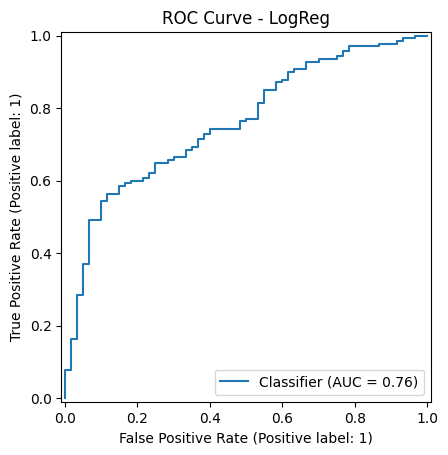


DecisionTree
Accuracy : 0.705
Precision: 0.7682119205298014
Recall   : 0.8285714285714286
F1       : 0.7972508591065293
ROC-AUC  : 0.6226190476190476
Confusion Matrix:
 [[ 25  35]
 [ 24 116]]

Classification Report:
               precision    recall  f1-score   support

         bad       0.51      0.42      0.46        60
        good       0.77      0.83      0.80       140

    accuracy                           0.70       200
   macro avg       0.64      0.62      0.63       200
weighted avg       0.69      0.70      0.70       200



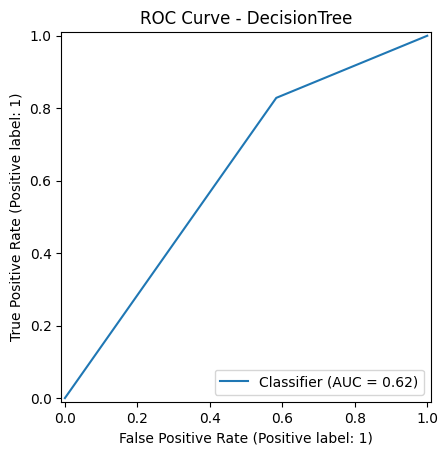


RandomForest
Accuracy : 0.74
Precision: 0.782051282051282
Recall   : 0.8714285714285714
F1       : 0.8243243243243243
ROC-AUC  : 0.7923214285714285
Confusion Matrix:
 [[ 26  34]
 [ 18 122]]

Classification Report:
               precision    recall  f1-score   support

         bad       0.59      0.43      0.50        60
        good       0.78      0.87      0.82       140

    accuracy                           0.74       200
   macro avg       0.69      0.65      0.66       200
weighted avg       0.72      0.74      0.73       200



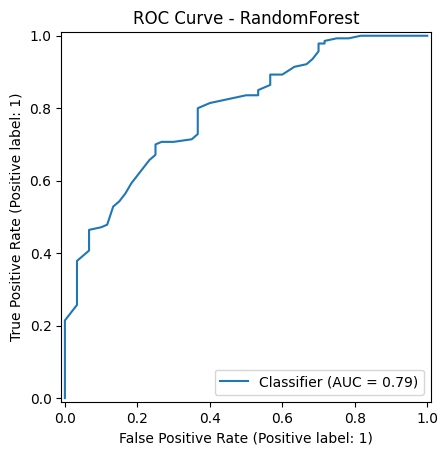

In [55]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)
import matplotlib.pyplot as plt

def evaluate_model(name, pipe, X_te, y_te):
    y_pred = pipe.predict(X_te)

    # positive class for ROC-AUC
    pos_label = pipe.named_steps["clf"].classes_[1]

    if hasattr(pipe.named_steps["clf"], "predict_proba"):
        y_score = pipe.predict_proba(X_te)[:, list(pipe.named_steps["clf"].classes_).index(pos_label)]
    else:
        y_score = pipe.decision_function(X_te)

    print("\n" + "="*60)
    print(name)
    print("Accuracy :", accuracy_score(y_te, y_pred))
    print("Precision:", precision_score(y_te, y_pred, pos_label=pos_label))
    print("Recall   :", recall_score(y_te, y_pred, pos_label=pos_label))
    print("F1       :", f1_score(y_te, y_pred, pos_label=pos_label))
    print("ROC-AUC  :", roc_auc_score((y_te == pos_label).astype(int), y_score))
    print("Confusion Matrix:\n", confusion_matrix(y_te, y_pred, labels=pipe.named_steps["clf"].classes_))
    print("\nClassification Report:\n", classification_report(y_te, y_pred))

    RocCurveDisplay.from_predictions((y_te == pos_label).astype(int), y_score)
    plt.title(f"ROC Curve - {name}")
    plt.show()

for name, pipe in models.items():
    evaluate_model(name, pipe, X_test, y_test)

## 6. Cross-Validation

To obtain reliable performance estimates, 5-fold stratified cross-validation is used.

This helps reduce overfitting and provides a robust comparison between models.

In [56]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "acc": "accuracy",
    "prec": "precision_macro",
    "rec": "recall_macro",
    "f1": "f1_macro",
    "roc": "roc_auc_ovr_weighted"
}

for name, pipe in models.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print("\n" + "="*60)
    print(name)
    print("CV Accuracy :", scores["test_acc"].mean())
    print("CV Precision:", scores["test_prec"].mean())
    print("CV Recall   :", scores["test_rec"].mean())
    print("CV F1       :", scores["test_f1"].mean())


LogReg
CV Accuracy : 0.73375
CV Precision: 0.7051220718064124
CV Recall   : 0.73125
CV F1       : 0.7084148455036594

DecisionTree
CV Accuracy : 0.6612500000000001
CV Precision: 0.599584696215424
CV Recall   : 0.6008928571428571
CV F1       : 0.5984259037452091

RandomForest
CV Accuracy : 0.76125
CV Precision: 0.7364741835477572
CV Recall   : 0.6473214285714285
CV F1       : 0.6600520991844013


## 7. Hyperparameter Tuning

GridSearchCV is applied to the Random Forest model to find the optimal hyperparameters.

The best model is selected based on F1-score.

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_pipe = models["RandomForest"]

param_grid = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [None, 10, 20],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    rf_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

best_model = grid.best_estimator_


Fitting 5 folds for each of 108 candidates, totalling 540 fits


## 8. Final Model Evaluation

The best tuned model is evaluated on the test set using:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- ROC-AUC  
- Confusion Matrix

In [ ]:

evaluate_model("Best RandomForest (GridSearch)", best_model, X_test, y_test)

## 9. Model Interpretation

Feature importance from the Random Forest model is analyzed to understand which variables most strongly influence credit risk predictions.

In [ ]:
import pandas as pd
import numpy as np

feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = best_model.named_steps["clf"].feature_importances_
fi = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

fi.head(15)

In [ ]:
import matplotlib.pyplot as plt

top = fi.head(15).iloc[::-1]
plt.figure()
plt.barh(top["feature"], top["importance"])
plt.title("Top 15 Feature Importances (RandomForest)")
plt.xlabel("Importance")
plt.show()

### Interpretation of Results

The most influential features include checking account status, credit amount, loan duration, age, and credit history.

Applicants with no checking account or negative balances tend to show higher credit risk. Larger credit amounts and longer durations also increase risk probability.

Among all tested models, Random Forest achieved the highest F1-score and ROC-AUC, making it the best-performing classifier for this task.

Overall, the model successfully captures key financial risk patterns and generalizes well to unseen data.